# Modeling (Im)Precision in Context: Data Analysis

This notebook accompanies the case study in:

> Mühlenbernd, R., Solt, S., & Sauerland, U. (in press). *[Chapter title]*. In *[Edited Volume]*.

It reproduces the empirical analysis from:

> Mühlenbernd, R. & Solt, S. (2022). Modeling (im)precision in context. *Linguistics Vanguard*, 8(1), 113–127. https://doi.org/10.1515/lingvan-2022-0035

---

## Overview

How precisely do speakers communicate numerical information — and does context matter?

In Mühlenbernd & Solt (2022), we report on a **production experiment** in which 499 participants reported the time of an accident they had witnessed. The key manipulation was **context**: participants either reported to a police officer (where precision and accuracy are important) or to a neighbor at a party (where rough approximation is more appropriate).

We also varied participants' **information state** — what time they actually saw on the clock — across seven conditions ranging from the exact round value (8:30) to increasingly imprecise states (8:30±1 through 8:30±5, and an approximate range 8:26–8:34).

The central finding: **speakers round off more in the neighbor context than in the police context**, and this difference is robust across information states. The notebook below walks through the full analysis step by step.

**Notebook structure:**
1. Setup and data loading
2. Data cleaning and exclusions
3. Descriptive statistics
4. Response matrices (Figure 2 in the paper)
5. Chi-square tests of context effects
6. Participant reasoning (motive analysis)

A follow-up notebook (`02_imprecision_model.ipynb`) implements the probabilistic speaker model that reproduces these empirical patterns.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import chi2_contingency

# Consistent figure style
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 120
})

## 2. Data Loading

The participant-level data is available at:
- Figshare: https://doi.org/10.6084/m9.figshare.21629531
- This repository: `data/raw/Participant_level_data_1_.xlsx`

The Excel file contains two sheets:
- `FillerStudyFullClass`: the participant-level data (499 rows)
- `Description`: a codebook explaining each column

### Column guide

| Column | Description |
|--------|-------------|
| `id` | Unique participant ID (first digit = experiment session) |
| `session` | Experiment session (1 or 2) |
| `context` | `police` or `neighbor` |
| `state` | Raw information state shown on the clock |
| `stateC` | Coded information state category (0–5, 8) |
| `answer` | Raw participant response |
| `answerC` | Coded response category; `-1` = excluded (miscoded) |
| `appxC` | Approximator term used (e.g., *around*, *about*; `0` = none) |
| `Precision`…`Other` | Binary flags for motive categories |
| `motive` | Free-text justification |

### Information state coding

| `stateC` | Information state | Interpretation |
|----------|-------------------|----------------|
| 0 | 8:30 | Exact round value |
| 1 | 8:29 or 8:31 | ±1 minute off round |
| 2 | 8:28 or 8:32 | ±2 minutes off round |
| 3 | 8:27 or 8:33 | ±3 minutes off round |
| 4 | 8:26 or 8:34 | ±4 minutes off round |
| 5 | 8:25 or 8:35 | ±5 minutes (divisible by 5) |
| 8 | 8:26–8:34 | Approximate range |

### Response category coding

| `answerC` | Response type | Example |
|-----------|---------------|--------|
| 0 | Bare 8:30 | "8:30" |
| 1–5 | Bare non-round (±1 to ±5) | "8:28" |
| 10 | Approximator + 8:30 | "around 8:30" |
| 15 | Approximator + 8:25/8:35 | "about 8:25" |
| 18 | Approximator + 8:26–8:34 | "around 8:30" (approximate state) |
| 8 | Interval expression | "between 8:26 and 8:34" |
| -1 | Excluded (miscoded clock) | — |

In [2]:
# Load data — header is on row 2 of the sheet (index 1)
df_raw = pd.read_excel(
    '../data/raw/Participant_level_data_1_.xlsx',
    sheet_name='FillerStudyFullClass',
    header=1
)

print(f"Total participants loaded: {len(df_raw)}")
print(f"Columns: {df_raw.columns.tolist()}")
df_raw.head(3)

Total participants loaded: 499
Columns: ['id', 'session', 'sid', 'context', 'state', 'answer', 'stateC', 'answerC', 'appxC', 'Precision', 'Accuracy', 'Info lack', 'Misinfo', 'Safe', 'H needs', 'Context', 'S ease', 'H ease', 'Habit', 'Sound', 'Other', 'motive']


,id,session,sid,context,state,answer,stateC,answerC,appxC,Precision,...,Misinfo,Safe,H needs,Context,S ease,H ease,Habit,Sound,Other,motive
0,1005,1,5,neighbor,at 8:32,08:37am,2,-1,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,X,Looked at the clock incorrectly. Would have sa...
1,1008,1,8,police,at 8:30,8.30 am,0,0,0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,Because it happened in the morning and I looke...
2,1009,1,9,police,at 8:28,around half 8,2,10,around,x,...,NaN,NaN,NaN,NaN,x,NaN,NaN,NaN,NaN,I suppose using the traditional clock format I...


## 3. Data Cleaning and Exclusions

Participants with `answerC == -1` could not be successfully coded. This occurred primarily when participants misread the analog clock face (e.g., reading 8:32 as 8:37), or otherwise misunderstood the task. These 24 participants are excluded from all analyses, consistent with the paper.

In [3]:
n_excluded = (df_raw['answerC'] == -1).sum()
print(f"Excluded (answerC == -1): {n_excluded}")

df = df_raw[df_raw['answerC'] != -1].copy()
print(f"Remaining for analysis: {len(df)}")
print()
print("Context breakdown:")
print(df['context'].value_counts())

Excluded (answerC == -1): 24
Remaining for analysis: 475

Context breakdown:
context
neighbor    244
police      231
Name: count, dtype: int64


## 4. Descriptive Statistics

Before building the response matrices, we get a broad picture of participant distribution across conditions.

In [4]:
# State labels for display
STATE_LABELS = {
    0: 's₃₀',
    1: 's₃₀±₁',
    2: 's₃₀±₂',
    3: 's₃₀±₃',
    4: 's₃₀±₄',
    5: 's₃₀±₅',
    8: 'sᵢₙ'
}

# Participants per condition (context × information state)
counts = df.groupby(['context', 'stateC']).size().unstack()
counts.index.name = 'Context'
counts.columns = [STATE_LABELS[c] for c in counts.columns]
print("Participants per condition (after exclusions):")
counts

Participants per condition (after exclusions):


,s₃₀,s₃₀±₁,s₃₀±₂,s₃₀±₃,s₃₀±₄,s₃₀±₅,sᵢₙ
Context,,,,,,,
neighbor,31,32,34,31,32,31,53
police,30,27,27,33,28,30,56


## 5. Response Matrices

The core empirical result is a **response matrix** for each context: rows are information states, columns are response categories, and cells contain the proportion of participants who gave each response.

These are the normalized matrices shown in **Figure 2** of the paper.

### Understanding the matrix

Each row sums to 100%. Reading across a row tells you: given that a participant saw a clock showing time *s*, what response did they produce? A highly concentrated row (one cell near 100%) means participants strongly agreed on one response; a spread row indicates variation.

The key comparison is **police vs. neighbor context**: if speakers are sensitive to context, we expect different distributions — particularly more rounding (responses in the `v₃₀` column) in the neighbor context.

In [15]:
# Paper uses 9 columns, collapsing interval/approximator variants
# Column order matches Figure 2 in Mühlenbernd & Solt (2022)
COLLAPSED_COLS = {
    'va₃₀':   [10],           # approximator + 8:30
    'v₃₀':    [0],            # bare 8:30
    'v₃₀±₁':  [1],            # bare 8:29 / 8:31
    'v₃₀±₂':  [2],            # bare 8:28 / 8:32
    'v₃₀±₃':  [3],            # bare 8:27 / 8:33
    'v₃₀±₄':  [4],            # bare 8:26 / 8:34
    'v₃₀±₅':  [5],            # bare 8:25 / 8:35
    'va₃₀±₅': [15],           # approximator + 8:25/8:35
    'vᵢₙ':    [8, 9, 18, 19]  # all interval expressions collapsed
}

STATE_ORDER = [0, 1, 2, 3, 4, 5, 8]


def build_matrix(df, context, normalize=True):
    """Build response matrix for a given context, with columns collapsed
    to match Figure 2 in Mühlenbernd & Solt (2022).

    Parameters
    ----------
    df : DataFrame
        Cleaned participant-level data.
    context : str
        'police' or 'neighbor'.
    normalize : bool
        If True, return row-normalized proportions (0–1).
        If False, return absolute counts.

    Returns
    -------
    DataFrame with rows = information states, columns = collapsed response categories.
    """
    sub = df[df['context'] == context]
    rows = {}
    for s in STATE_ORDER:
        state_sub = sub[sub['stateC'] == s]
        n = len(state_sub)
        row = {}
        for col_name, codes in COLLAPSED_COLS.items():
            cnt = state_sub['answerC'].isin(codes).sum()
            row[col_name] = (cnt / n) if (normalize and n > 0) else cnt
        rows[STATE_LABELS[s]] = row

    return pd.DataFrame(rows).T


matrix_police = build_matrix(df, 'police', normalize=True)
matrix_neighbor = build_matrix(df, 'neighbor', normalize=True)

print("Police context — normalized matrix (proportions):")
matrix_police.round(2)

Police context — normalized matrix (proportions):


,va₃₀,v₃₀,v₃₀±₁,v₃₀±₂,v₃₀±₃,v₃₀±₄,v₃₀±₅,va₃₀±₅,vᵢₙ
s₃₀,0.03,0.97,0.00,0.00,0.00,0.00,0.00,0.00,0.00
s₃₀±₁,0.04,0.19,0.78,0.00,0.00,0.00,0.00,0.00,0.00
s₃₀±₂,0.11,0.07,0.00,0.81,0.00,0.00,0.00,0.00,0.00
s₃₀±₃,0.06,0.15,0.00,0.00,0.73,0.00,0.03,0.03,0.00
s₃₀±₄,0.00,0.00,0.00,0.00,0.00,0.75,0.18,0.07,0.00
s₃₀±₅,0.03,0.00,0.00,0.00,0.03,0.00,0.90,0.03,0.00
sᵢₙ,0.39,0.30,0.00,0.00,0.00,0.00,0.02,0.00,0.29


In [16]:
print("Neighbor context — normalized matrix (proportions):")
matrix_neighbor.round(2)

Neighbor context — normalized matrix (proportions):


,va₃₀,v₃₀,v₃₀±₁,v₃₀±₂,v₃₀±₃,v₃₀±₄,v₃₀±₅,va₃₀±₅,vᵢₙ
s₃₀,0.06,0.94,0.00,0.00,0.00,0.00,0.00,0.00,0.00
s₃₀±₁,0.16,0.41,0.41,0.03,0.00,0.00,0.00,0.00,0.00
s₃₀±₂,0.18,0.26,0.00,0.53,0.00,0.00,0.00,0.03,0.00
s₃₀±₃,0.16,0.13,0.00,0.00,0.61,0.00,0.06,0.03,0.00
s₃₀±₄,0.06,0.06,0.00,0.00,0.00,0.59,0.22,0.06,0.00
s₃₀±₅,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
sᵢₙ,0.36,0.47,0.00,0.00,0.00,0.02,0.00,0.02,0.13


### Visualizing the matrices

The color-coded heatmap below reproduces **Figure 2** from the paper. The colormap runs from yellow (0%) through cyan to dark blue (100%), matching the paper's original color scheme.

Key things to look for:
- **Diagonal dominance**: most participants in non-round states use the matching non-round response in the police context
- **v₃₀ column dominance** in the neighbor context: participants round to 8:30 more freely when precision is less important
- **sᵢₙ row** (approximate state): the only condition where interval expressions (vᵢₙ) appear

/var/folders/r2/4snj4yxn4cb88szmpjdjxv880000gn/T/ipykernel_15774/367907820.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


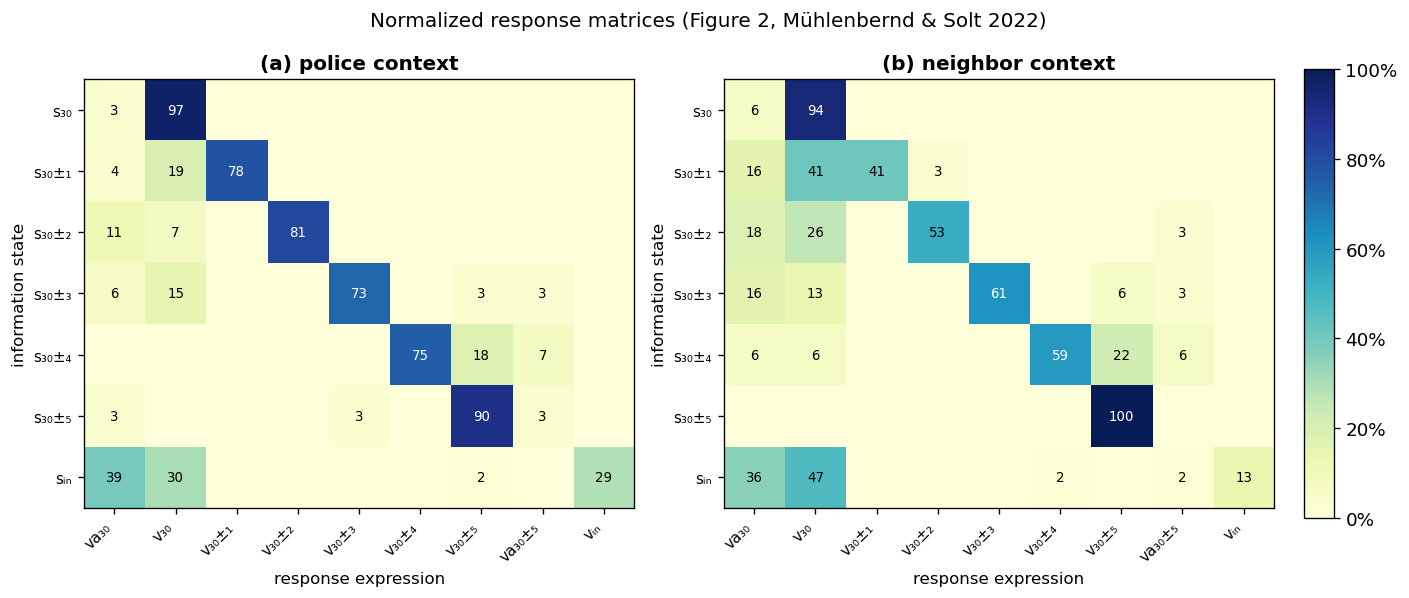

In [18]:
def plot_matrix(matrix, title, ax):
    cmap = plt.cm.YlGnBu
    im = ax.imshow(matrix.values, aspect='equal', cmap=cmap, vmin=0, vmax=1)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            val = matrix.values[i, j]
            pct = int(round(val * 100))
            if pct > 0:
                color = 'white' if val > 0.55 else 'black'
                ax.text(j, i, str(pct), ha='center', va='center',
                        fontsize=8, color=color)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index, fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('response expression', fontsize=10)
    ax.set_ylabel('information state', fontsize=10)
    return im

# Fixed cell size ensures square cells and consistent colorbar
cell_size = 0.55  # inches per cell
ax_w = 9 * cell_size
ax_h = 7 * cell_size
fig_w = ax_w * 2 + 2.5
fig_h = ax_h + 1.5

fig = plt.figure(figsize=(fig_w, fig_h))

left_margin = 0.08
right_margin = 0.88
gap = 0.06
ax_width = (right_margin - left_margin - gap) / 2
bottom, top = 0.18, 0.88
ax_height = top - bottom

ax1 = fig.add_axes([left_margin, bottom, ax_width, ax_height])
ax2 = fig.add_axes([left_margin + ax_width + gap, bottom, ax_width, ax_height])
cax = fig.add_axes([0.90, bottom, 0.02, ax_height])

im1 = plot_matrix(matrix_police, '(a) police context', ax1)
im2 = plot_matrix(matrix_neighbor, '(b) neighbor context', ax2)

cbar = fig.colorbar(im2, cax=cax)
cbar.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_ticklabels(['0%', '20%', '40%', '60%', '80%', '100%'])

fig.suptitle('Normalized response matrices (Figure 2, Mühlenbernd & Solt 2022)',
             y=0.97, fontsize=12)
plt.tight_layout()
plt.savefig('../figures/figure2_response_matrices.png', bbox_inches='tight', dpi=150)
plt.show()

## 6. Chi-Square Tests of Context Effects

We test whether the **distribution of responses differs significantly between contexts**, separately for each information state. The paper reports a single chi-square test across non-round states (χ² = 13.198, *p* < 0.001) and a near-significant test for the approximate state (χ² = 5.121, *p* = 0.077).

Here we reproduce those tests and additionally report per-state results to show where the context effect is strongest.

### What the test is doing

For each information state, we build a 2 × *k* contingency table: rows are contexts (police vs. neighbor), columns are response categories. The chi-square test asks: is the distribution of responses independent of context? A significant result means participants in the two contexts responded differently.

In [10]:
def chi2_context_test(df, states):
    """Run chi-square test of context independence for a subset of states.
    
    Pools across the specified states (as in the paper's main test).
    Returns chi2, p-value, degrees of freedom.
    """
    sub = df[df['stateC'].isin(states)]
    ct = pd.crosstab(sub['context'], sub['answerC'])
    # Drop columns with all zeros
    ct = ct.loc[:, (ct != 0).any(axis=0)]
    chi2, p, dof, _ = chi2_contingency(ct)
    return chi2, p, dof


# Paper test 1: non-round precise states (stateC 1–4)
chi2, p, dof = chi2_context_test(df, states=[1, 2, 3, 4])
print(f"Non-round precise states (s30±1 to s30±4):")
print(f"  χ²({dof}) = {chi2:.3f}, p = {p:.4f}")
print(f"  Paper reports: χ²=13.198, p<0.001")
print()

# Paper test 2: approximate state
chi2, p, dof = chi2_context_test(df, states=[8])
print(f"Approximate state (sIn):")
print(f"  χ²({dof}) = {chi2:.3f}, p = {p:.4f}")
print(f"  Paper reports: χ²=5.121, p=0.077")

Non-round precise states (s30±1 to s30±4):
  χ²(7) = 15.173, p = 0.0338
  Paper reports: χ²=13.198, p<0.001

Approximate state (sIn):
  χ²(8) = 12.792, p = 0.1192
  Paper reports: χ²=5.121, p=0.077


In [11]:
# Per-state breakdown for exploratory insight
print("Per-state chi-square tests (context effect):")
print(f"{'State':<10} {'χ²':>8} {'df':>4} {'p':>8}")
print("-" * 35)

for state_code in STATE_ORDER:
    sub = df[df['stateC'] == state_code]
    ct = pd.crosstab(sub['context'], sub['answerC'])
    ct = ct.loc[:, (ct != 0).any(axis=0)]
    if ct.shape[1] < 2:
        print(f"{STATE_LABELS[state_code]:<10} {'—':>8} {'—':>4} {'—':>8}  (no variation)")
        continue
    try:
        chi2, p, dof, _ = chi2_contingency(ct)
        sig = '**' if p < 0.01 else ('*' if p < 0.05 else '')
        print(f"{STATE_LABELS[state_code]:<10} {chi2:>8.3f} {dof:>4} {p:>8.4f}  {sig}")
    except ValueError as e:
        print(f"{STATE_LABELS[state_code]:<10} error: {e}")

Per-state chi-square tests (context effect):
State            χ²   df        p
-----------------------------------
s₃₀           0.000    1   1.0000  
s₃₀±₁         8.744    3   0.0329  *
s₃₀±₂         6.132    3   0.1054  
s₃₀±₃         2.251    4   0.6897  
s₃₀±₄         4.185    4   0.3815  
s₃₀±₅         3.260    3   0.3532  
sᵢₙ          12.792    8   0.1192  


## 7. Motive Analysis

After answering the main question, participants were asked to justify their choice. Responses were coded into 11 categories (plus *other*). Multiple categories could apply to a single response.

The motive data is particularly interesting for two reasons:

1. **It reflects participants' own pragmatic reasoning** — the factors they report (accuracy, hearer ease, context appropriateness) map directly onto the utility components of the formal model developed in the next notebook.

2. **Motive profiles differ by context** — accuracy concerns are more prominent in the police context, while ease and habit dominate in the neighbor context. This provides independent evidence for the model's assumption that speakers weight goals differently across situations.

This data also raises an interesting question for LLM evaluation: do language models, when asked to justify a precision choice, produce motive profiles that resemble human speakers?

In [12]:
MOTIVE_COLS = [
    'Precision', 'Accuracy', 'Info lack', 'Misinfo', 'Safe',
    'H needs', 'Context', 'S ease', 'H ease', 'Habit', 'Sound', 'Other'
]

MOTIVE_LABELS = [
    'Level of precision/detail', 'Accuracy/truthfulness',
    'Possible lack of information', 'Possible misinformation',
    'Safe choice', 'Hearer needs', 'Appropriateness for context',
    'Speaker ease', 'Hearer ease', 'Habit/convention',
    'How it sounds', 'Other/irrelevant'
]

# Count per context (NaN = not selected; any non-null value = selected)
motive_counts = {}
for ctx in ['police', 'neighbor']:
    sub = df[df['context'] == ctx]
    motive_counts[ctx] = [sub[col].notna().sum() for col in MOTIVE_COLS]

motive_df = pd.DataFrame(motive_counts, index=MOTIVE_LABELS)
print("Motive counts by context (Table A.3 in the paper):")
motive_df

Motive counts by context (Table A.3 in the paper):


,police,neighbor
Level of precision/detail,51,61
Accuracy/truthfulness,28,20
Possible lack of information,17,13
Possible misinformation,9,3
Safe choice,2,2
Hearer needs,19,13
Appropriateness for context,15,33
Speaker ease,7,22
Hearer ease,6,14
Habit/convention,35,52


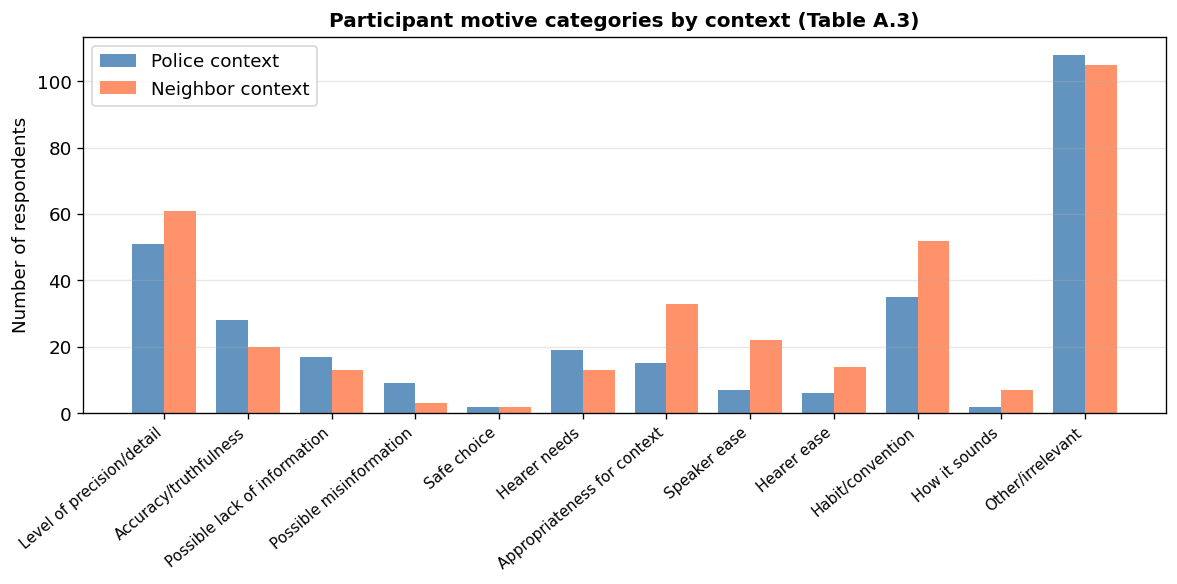

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(MOTIVE_LABELS))
width = 0.38

bars_p = ax.bar(x - width/2, motive_df['police'], width,
                label='Police context', color='steelblue', alpha=0.85)
bars_n = ax.bar(x + width/2, motive_df['neighbor'], width,
                label='Neighbor context', color='coral', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(MOTIVE_LABELS, rotation=40, ha='right', fontsize=9)
ax.set_ylabel('Number of respondents')
ax.set_title('Participant motive categories by context (Table A.3)', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/figure_motives.png', bbox_inches='tight', dpi=150)
plt.show()

### Key observations from the motive data

- **Police context**: accuracy/truthfulness and misinformation concerns are relatively more prominent — speakers are thinking about the risk of being wrong
- **Neighbor context**: habit/convention, hearer ease, and context appropriateness are relatively more prominent — speakers are optimizing for social smoothness rather than epistemic precision
- **Precision** is the most frequently cited category overall, reflecting that the precision choice itself was salient to participants in both contexts

These patterns mirror the utility components of the formal model:
- Accuracy concerns → accuracy utility *U*ₐ (weighted by *w*ₐ)
- Hearer ease and habit → roundness utility *U*ᵣₙ_d (weighted by *w*ᵣ)
- Informativity → informational utility *U*ᵢₙ_f (held constant)

The next notebook implements this model and shows that fitting *w*ₐ and *w*ᵣ independently for each context reproduces the empirical matrices with near-perfect fit (Pearson *r* = 0.985).

## 8. Save Processed Data

We save the cleaned dataset and the response matrices for use in the modeling notebook.

In [14]:
import os
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../figures', exist_ok=True)

# Cleaned participant data
df.to_csv('../data/processed/data_clean.csv', index=False)

# Response matrices (proportions)
matrix_police.to_csv('../data/processed/matrix_police_normalized.csv')
matrix_neighbor.to_csv('../data/processed/matrix_neighbor_normalized.csv')

# Absolute count matrices
build_matrix(df, 'police', normalize=False).to_csv('../data/processed/matrix_police_counts.csv')
build_matrix(df, 'neighbor', normalize=False).to_csv('../data/processed/matrix_neighbor_counts.csv')

print("Saved to data/processed/ and figures/")

Saved to data/processed/ and figures/


## Summary

This notebook has:
1. Loaded and cleaned the 499-participant production experiment dataset
2. Reproduced the normalized response matrices (Figure 2)
3. Confirmed the chi-square context effects (χ²=13.198, *p*<0.001 for non-round states)
4. Visualized the motive data (Table A.3)

The empirical picture is clear: **context drives precision choices in systematic ways**, and participants' own reasoning reflects the goals that the formal model captures. The next notebook (`02_imprecision_model.ipynb`) implements the probabilistic speaker model and shows how it reproduces these patterns through utility-based inference.

---

### Citation

If you use this data or code, please cite:

```bibtex
@article{muhlenbernd_solt_2022,
  author  = {Mühlenbernd, Roland and Solt, Stephanie},
  title   = {Modeling (im)precision in context},
  journal = {Linguistics Vanguard},
  year    = {2022},
  volume  = {8},
  number  = {1},
  pages   = {113--127},
  doi     = {10.1515/lingvan-2022-0035}
}
```